# Insurance Claim Cost Prediction — Complete Project

**Project topic:** Predicting insurance claim costs using the Kaggle Allstate Claims Severity dataset.

**Stakeholder:** Insurance Claims Managers  
**Business goal:** Predict claim costs so managers can set better reserves, identify potentially expensive claims, and allocate resources.

This notebook covers:
- Dataset loading and data-fit evaluation
- Dataset limitations
- Data cleaning
- Exploratory Data Analysis (EDA)
- Business insight
- Analysis plan
- Linear Regression
- Random Forest
- Gradient Boosting
- Model comparison and tuning
- Final evaluation
- Visualizations/dashboard
- Final conclusion


## 1. Dataset Source

The dataset is the **Allstate Claims Severity** training dataset from Kaggle.

The training file contains anonymized categorical (`cat`) and continuous (`cont`) predictors and the target variable `loss`.


In [68]:
# Import libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
FILE = "train(20260808-020256).csv"
df = pd.read_csv('/Users/prakashghatani/Desktop/Regis/MSDS696_Practicum 2/train.csv')

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (188318, 132)


,id,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,...,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,loss
0,1,A,B,A,B,A,A,A,A,B,...,0.718367,0.335060,0.30260,0.67135,0.83510,0.569745,0.594646,0.822493,0.714843,2213.18
1,2,A,B,A,A,A,A,A,A,B,...,0.438917,0.436585,0.60087,0.35127,0.43919,0.338312,0.366307,0.611431,0.304496,1283.60
2,5,A,B,A,A,B,A,A,A,B,...,0.289648,0.315545,0.27320,0.26076,0.32446,0.381398,0.373424,0.195709,0.774425,3005.09
3,10,B,B,A,B,A,A,A,A,B,...,0.440945,0.391128,0.31796,0.32128,0.44467,0.327915,0.321570,0.605077,0.602642,939.85
4,11,A,B,A,B,A,A,A,A,B,...,0.178193,0.247408,0.24564,0.22089,0.21230,0.204687,0.202213,0.246011,0.432606,2763.85


## 2. Data-Fit Evaluation

**Fit:** The dataset fits the project because `loss` is a continuous dollar-value target suitable for regression.

**Provenance:** The data comes from the Kaggle Allstate Claims Severity competition.

**Limits:** Predictors are anonymized, claim loss is strongly right-skewed, and the dataset does not contain claim dates or detailed policy context.

**Feasibility:** The dataset can be analyzed with pandas and scikit-learn and is large enough for training and testing machine-learning models.


## 3. Three Dataset Limitations

1. **Anonymized features:** Variables such as `cat1` and `cont1` do not have business descriptions, which limits interpretation.
2. **Skewed target:** Most claims are relatively small while a few claims are very expensive.
3. **Limited context:** The dataset does not include claim dates, policy details, or external factors, so results may not generalize to every insurer or time period.


In [69]:
# Basic data inspection
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nDuplicate rows:", df.duplicated().sum())
print("\nMissing values:", df.isnull().sum().sum())
print("\nTarget summary:")
print(df["loss"].describe())


Rows: 188318
Columns: 132

Duplicate rows: 0

Missing values: 0

Target summary:
count    188318.000000
mean       3037.337686
std        2904.086186
min           0.670000
25%        1204.460000
50%        2115.570000
75%        3864.045000
max      121012.250000
Name: loss, dtype: float64


## 4. Data Cleaning

The following steps remove the identifier from modeling, check duplicates/missing values, and identify categorical and numerical predictors.


In [70]:
# Remove duplicate rows
df = df.drop_duplicates().copy()

# Separate target and ID
target = "loss"
drop_cols = ["id"] if "id" in df.columns else []

X = df.drop(columns=[target] + drop_cols)
y = df[target].copy()

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

print("Clean shape:", df.shape)
print("Categorical features:", len(categorical_cols))
print("Numeric features:", len(numeric_cols))
print("Missing values after basic cleaning:", df.isnull().sum().sum())


Clean shape: (188318, 132)
Categorical features: 116
Numeric features: 14
Missing values after basic cleaning: 0


## 5. Exploratory Data Analysis (EDA)

We examine the claim-loss distribution and summarize claims into business-friendly cost ranges.


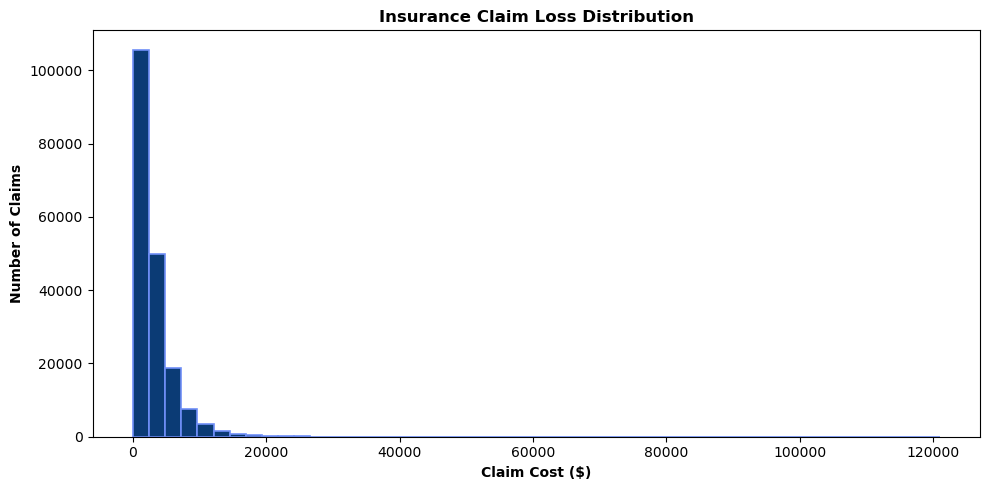

In [71]:
# Loss Distribution
plt.figure(figsize=(10, 5))



plt.hist(
    df["loss"],
    bins=50,
    color="#0B3B75",      # Dark blue
    edgecolor="#6F8FF7",  # Light blue
    linewidth=1.2
)

plt.title("Insurance Claim Loss Distribution", fontweight="bold")
plt.xlabel("Claim Cost ($)", fontweight="bold")
plt.ylabel("Number of Claims", fontweight="bold")

plt.tight_layout()
plt.show()


In [72]:
# Claim cost ranges
bins = [0, 5000, 10000, 20000, 40000, np.inf]
labels = ["$0–5K", "$5K–10K", "$10K–20K", "$20K–40K", "$40K+"]

df["Claim Range"] = pd.cut(
    df["loss"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

claim_counts = df["Claim Range"].value_counts().sort_index()
claim_percent = (claim_counts / len(df) * 100).round(2)

eda_table = pd.DataFrame({
    "Claim Count": claim_counts,
    "Percent": claim_percent
})

eda_table


,Claim Count,Percent
Claim Range,,
$0–5K,157412,83.59
$5K–10K,25026,13.29
$10K–20K,5442,2.89
$20K–40K,415,0.22
$40K+,23,0.01


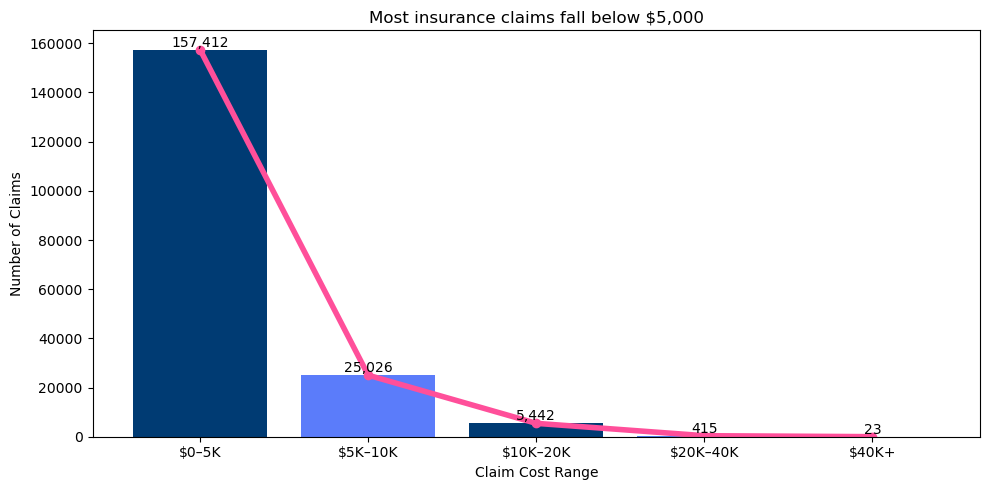

In [73]:
# Business insight chart
plt.figure(figsize=(10, 5))

# Blue bar colors
colors = [
    "#003B73",
    "#5B7CFA",
    "#003B73",
    "#4F7DF3",
    "#0057B8",
    "#003B73",
    "#4F7DF3"
]

bars = plt.bar(
    claim_counts.index.astype(str),
    claim_counts.values,
    color=colors
)

# Pink line
plt.plot(
    claim_counts.index.astype(str),
    claim_counts.values,
    color="#FF4F9A",
    linewidth=4,
    marker="o"
)

plt.title("Most insurance claims fall below $5,000")
plt.xlabel("Claim Cost Range")
plt.ylabel("Number of Claims")

# Values above bars
for bar, value in zip(bars, claim_counts.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 6. Business Insight

Most insurance claims are in the lower-cost range, while very expensive claims are rare. Even though high-cost claims occur less often, they can create significant financial risk.

**Business action:** Claims managers can use predictive models to identify potentially expensive claims earlier, set more accurate reserves, and assign experienced adjusters where needed.


## 7. Analysis Plan

1. Split the data into training and testing sets.
2. Preprocess categorical and numerical variables.
3. Train a **Linear Regression** baseline.
4. Compare it with **Random Forest** and **Gradient Boosting**.
5. Evaluate models using **R², MAE, and RMSE**.
6. Tune the strongest tree-based model.
7. Select the final model based on test-set performance and business usefulness.


In [74]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 150654
Testing rows: 37664


In [75]:
# Helper function
results = []

def evaluate_model(name, model, X_test, y_test):
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    print(name)
    print(f"MAE : ${mae:,.2f}")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"R²  : {r2:.4f}")
    return pred


## 8. First Regression Model — Linear Regression

In [76]:
# Preprocessing for Linear Regression
linear_preprocess = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_cols),

    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_cols)
])

linear_model = Pipeline([
    ("preprocess", linear_preprocess),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_pred = evaluate_model(
    "Linear Regression",
    linear_model,
    X_test,
    y_test
)


Linear Regression
MAE : $1,291.42
RMSE: $2,016.61
R²  : 0.5016


## 9. Random Forest and Gradient Boosting

For tree models, categorical variables are ordinal-encoded to keep the transformed dataset compact and make training practical.


In [77]:
# Preprocessing for tree models
tree_preprocess = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]), numeric_cols),

    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        ))
    ]), categorical_cols)
])

# Transform once for faster tree-model training
X_train_tree = tree_preprocess.fit_transform(X_train)
X_test_tree = tree_preprocess.transform(X_test)

print("Tree training matrix:", X_train_tree.shape)


Tree training matrix: (150654, 130)


In [78]:
# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tree, y_train)
rf_pred = evaluate_model(
    "Random Forest",
    rf_model,
    X_test_tree,
    y_test
)


Random Forest
MAE : $1,226.57
RMSE: $1,903.31
R²  : 0.5560


In [79]:
# Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_tree, y_train)
gb_pred = evaluate_model(
    "Gradient Boosting",
    gb_model,
    X_test_tree,
    y_test
)


Gradient Boosting
MAE : $1,261.99
RMSE: $1,945.67
R²  : 0.5361


## 10. Model Comparison

In [80]:
# Compare baseline models
comparison = pd.DataFrame(results).sort_values("RMSE")
comparison


,Model,MAE,RMSE,R2
1,Random Forest,1226.566130,1903.307162,0.556035
2,Gradient Boosting,1261.994749,1945.669295,0.536052
0,Linear Regression,1291.423102,2016.609287,0.501604


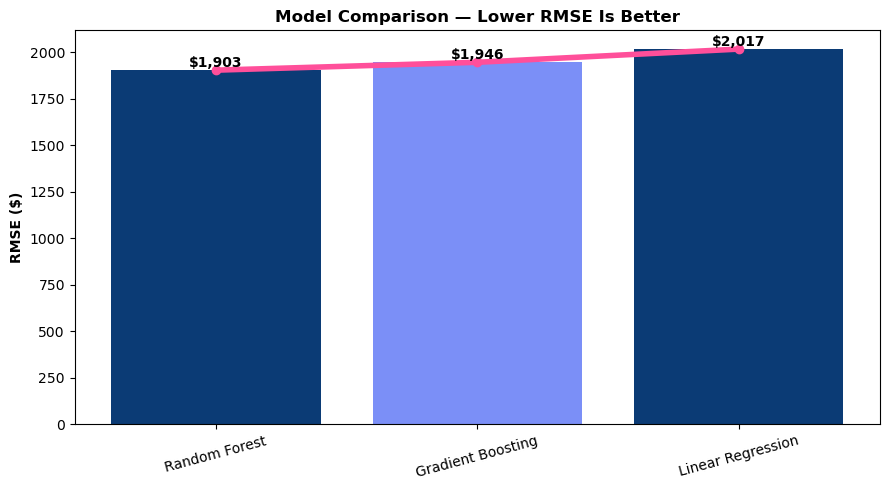

In [81]:
# Model Comparison Chart
plt.figure(figsize=(9, 5))

# Blue colors
colors = ["#0B3B75", "#7B8FF7", "#0B3B75"]

bars = plt.bar(
    comparison["Model"],
    comparison["RMSE"],
    color=colors[:len(comparison)]
)

# Pink comparison line
plt.plot(
    comparison["Model"],
    comparison["RMSE"],
    color="#FF4F9A",
    linewidth=4,
    marker="o"
)

plt.title("Model Comparison — Lower RMSE Is Better",
          fontweight="bold")
plt.ylabel("RMSE ($)", fontweight="bold")
plt.xticks(rotation=15)

# Add RMSE values
for i, value in enumerate(comparison["RMSE"]):
    plt.text(
        i,
        value,
        f"${value:,.0f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


## 11. Model Tuning — Gradient Boosting

Randomized search tests several Gradient Boosting settings. To keep the notebook practical, tuning uses a training sample while final evaluation uses the full held-out test set.


In [82]:
# Use a reproducible tuning sample for faster search
rng = np.random.RandomState(42)
tune_size = min(60000, X_train_tree.shape[0])
tune_idx = rng.choice(X_train_tree.shape[0], size=tune_size, replace=False)

X_tune = X_train_tree[tune_idx]
y_tune = y_train.iloc[tune_idx]

param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.03, 0.05, 0.10],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [1, 3, 5]
}

search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=8,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_tune, y_tune)

print("Best parameters:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters: {'n_estimators': 150, 'min_samples_leaf': 5, 'max_depth': 3, 'learning_rate': 0.1}
Best CV RMSE: 2074.3795617464093


In [83]:
# Refit tuned model on full training data
tuned_gb = GradientBoostingRegressor(
    random_state=42,
    **search.best_params_
)

tuned_gb.fit(X_train_tree, y_train)

tuned_pred = tuned_gb.predict(X_test_tree)

tuned_mae = mean_absolute_error(y_test, tuned_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))
tuned_r2 = r2_score(y_test, tuned_pred)

print("Tuned Gradient Boosting")
print(f"MAE : ${tuned_mae:,.2f}")
print(f"RMSE: ${tuned_rmse:,.2f}")
print(f"R²  : {tuned_r2:.4f}")


Tuned Gradient Boosting
MAE : $1,218.61
RMSE: $1,884.82
R²  : 0.5646


In [84]:
# Professor-requested analysis: Top 5% high-cost claim capture
# Run this cell after tuned_pred has been created.

results_df = pd.DataFrame({
    "actual_loss": y_test.to_numpy(),
    "predicted_loss": tuned_pred
})

# Rank held-out test claims from highest to lowest predicted cost.
results_df = results_df.sort_values(
    "predicted_loss", ascending=False
).reset_index(drop=True)

# Select the top 5% of scored claims.
top_5_n = int(np.ceil(len(results_df) * 0.05))
top_5 = results_df.head(top_5_n)

# Define high-cost claims as actual loss above $40,000.
high_cost_test = results_df[results_df["actual_loss"] > 40000]
captured_high_cost = top_5[top_5["actual_loss"] > 40000]

total_high_cost = len(high_cost_test)
captured = len(captured_high_cost)
capture_rate = (captured / total_high_cost * 100) if total_high_cost else 0.0

print("PROFESSOR-REQUESTED TOP-5% RESULT")
print(f"Held-out test claims: {len(results_df):,}")
print(f"Top 5% reviewed: {top_5_n:,}")
print(f"$40,000+ claims in held-out test set: {total_high_cost}")
print(f"$40,000+ claims captured in top 5%: {captured}")
print(f"Capture rate: {capture_rate:.1f}%")

print("\nFINAL SLIDE WORDING")
print(
    f"The top 5% of model-scored claims captured {captured} of "
    f"{total_high_cost} claims above $40,000 in the held-out test set "
    f"({capture_rate:.1f}%)."
)


PROFESSOR-REQUESTED TOP-5% RESULT
Held-out test claims: 37,664
Top 5% reviewed: 1,884
$40,000+ claims in held-out test set: 6
$40,000+ claims captured in top 5%: 6
Capture rate: 100.0%

FINAL SLIDE WORDING
The top 5% of model-scored claims captured 6 of 6 claims above $40,000 in the held-out test set (100.0%).


## 12. Final Evaluation

In [85]:
# Add tuned model and create final score table
final_results = pd.concat([
    pd.DataFrame(results),
    pd.DataFrame([{
        "Model": "Tuned Gradient Boosting",
        "MAE": tuned_mae,
        "RMSE": tuned_rmse,
        "R2": tuned_r2
    }])
], ignore_index=True)

final_results = final_results.sort_values("RMSE").reset_index(drop=True)
final_results


,Model,MAE,RMSE,R2
0,Tuned Gradient Boosting,1218.606212,1884.816569,0.564619
1,Random Forest,1226.566130,1903.307162,0.556035
2,Gradient Boosting,1261.994749,1945.669295,0.536052
3,Linear Regression,1291.423102,2016.609287,0.501604


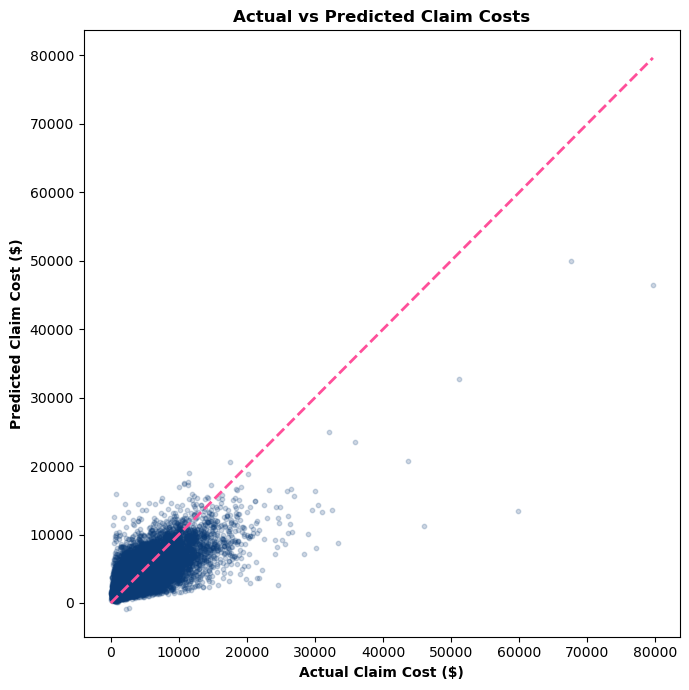

In [86]:
# Actual vs Predicted Visualization
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    tuned_pred,
    alpha=0.20,
    s=10,
    color="#0B3B75"
)

limit = max(y_test.max(), tuned_pred.max())

plt.plot(
    [0, limit],
    [0, limit],
    color="#FF4F9A",
    linestyle="--",
    linewidth=2
)

plt.title("Actual vs Predicted Claim Costs", fontweight="bold")
plt.xlabel("Actual Claim Cost ($)", fontweight="bold")
plt.ylabel("Predicted Claim Cost ($)", fontweight="bold")

plt.tight_layout()
plt.show()


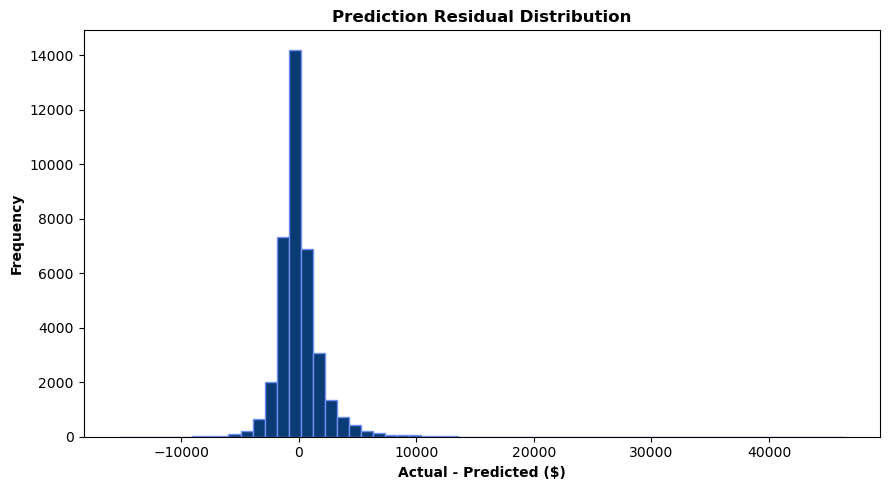

In [87]:
# Residual visualization
residuals = y_test.to_numpy() - tuned_pred

plt.figure(figsize=(9, 5))

plt.hist(
    residuals,
    bins=60,
    color="#0B3B75",      # Dark blue
    edgecolor="#6F8FF7",  # Light blue
    linewidth=1
)

plt.title("Prediction Residual Distribution", fontweight="bold")
plt.xlabel("Actual - Predicted ($)", fontweight="bold")
plt.ylabel("Frequency", fontweight="bold")

plt.tight_layout()
plt.show()


## 13. Visualization Dashboard

The dashboard below combines the most important project results:
- Claim-cost distribution
- Claim-cost ranges
- Model comparison
- Actual versus predicted values


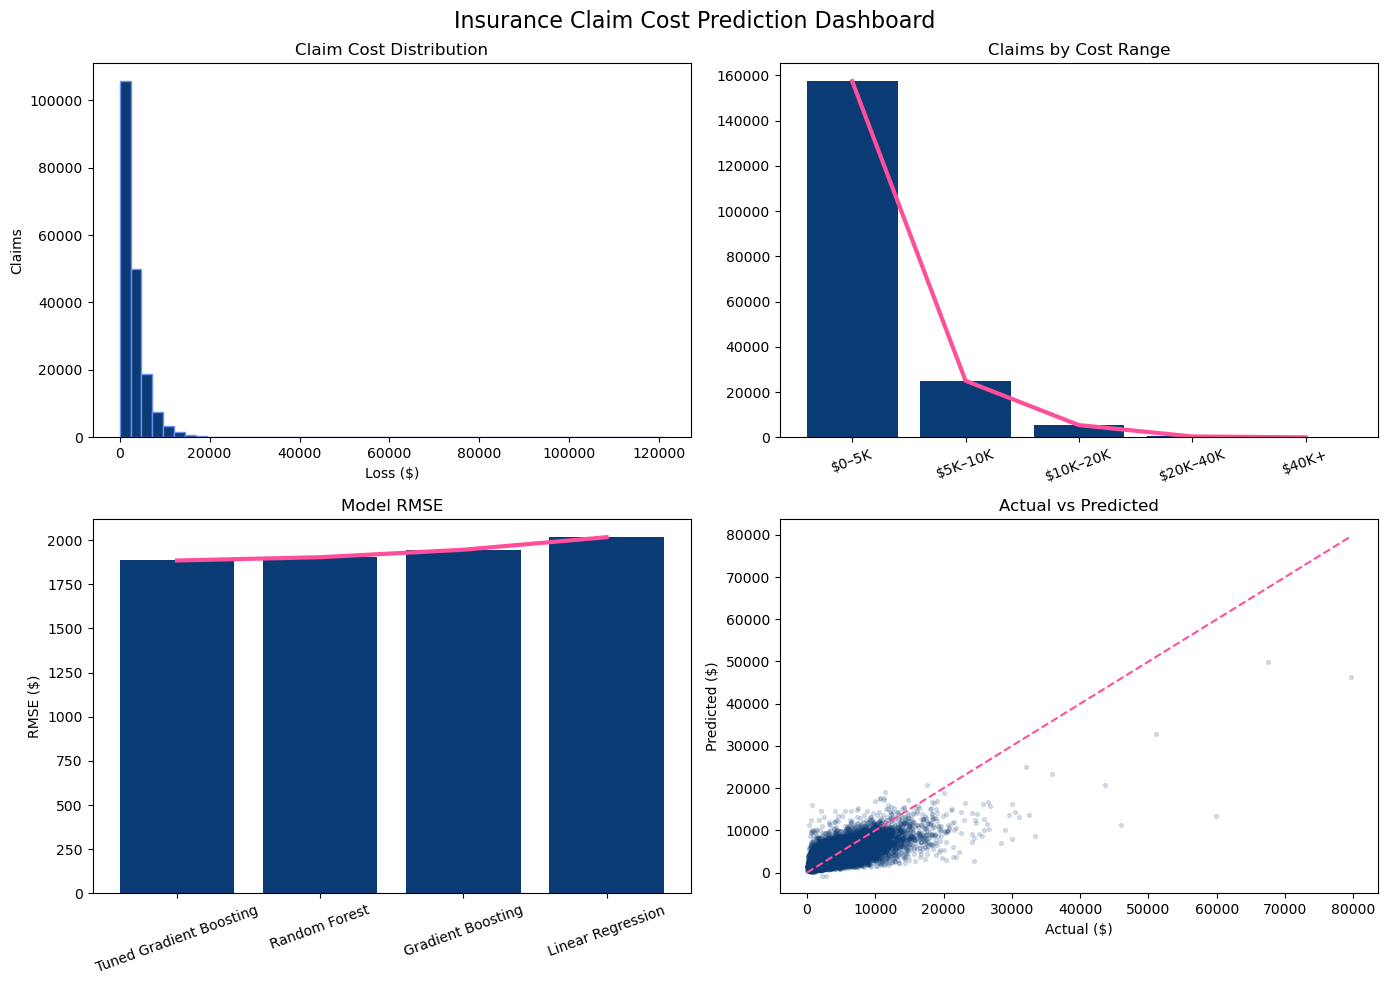

Exception ignored in: <function ResourceTracker.__del__ at 0x1051f3100>
Traceback (most recent call last):
  File "/opt/homebrew/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/homebrew/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/homebrew/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106dbb100>
Traceback (most recent call last):
  File "/opt/homebrew/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/homebrew/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/homebrew/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__

In [ ]:
# Simple 2x2 project dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

dark_blue = "#0B3B75"
light_blue = "#6F8FF7"
pink = "#FF4F9A"

# 1. Loss distribution
axes[0, 0].hist(df["loss"], bins=50, color=dark_blue, edgecolor=light_blue)
axes[0, 0].set_title("Claim Cost Distribution")
axes[0, 0].set_xlabel("Loss ($)")
axes[0, 0].set_ylabel("Claims")

# 2. Claim ranges
axes[0, 1].bar(claim_counts.index.astype(str), claim_counts.values, color=dark_blue)
axes[0, 1].plot(claim_counts.index.astype(str), claim_counts.values, color=pink, linewidth=3)
axes[0, 1].set_title("Claims by Cost Range")
axes[0, 1].tick_params(axis="x", rotation=20)

# 3. Model RMSE
axes[1, 0].bar(final_results["Model"], final_results["RMSE"], color=dark_blue)
axes[1, 0].plot(final_results["Model"], final_results["RMSE"], color=pink, linewidth=3)
axes[1, 0].set_title("Model RMSE")
axes[1, 0].set_ylabel("RMSE ($)")
axes[1, 0].tick_params(axis="x", rotation=20)

# 4. Actual vs predicted
axes[1, 1].scatter(y_test, tuned_pred, alpha=0.15, s=8, color=dark_blue)
axes[1, 1].plot([0, limit], [0, limit], color=pink, linestyle="--")
axes[1, 1].set_title("Actual vs Predicted")
axes[1, 1].set_xlabel("Actual ($)")
axes[1, 1].set_ylabel("Predicted ($)")

plt.suptitle("Insurance Claim Cost Prediction Dashboard", fontsize=16)
plt.tight_layout()
plt.show()

## 14. Final Report / Conclusion

This project used the Allstate Claims Severity dataset to predict insurance claim costs.

The analysis:
- Loaded and evaluated the Kaggle dataset.
- Identified three important data limitations.
- Cleaned and explored the data.
- Found that most claims are relatively low cost while a small number are very expensive.
- Built Linear Regression, Random Forest, and Gradient Boosting models.
- Tuned Gradient Boosting and evaluated the final model using R², MAE, and RMSE.

**Business recommendation:** Use the prediction model as a decision-support tool to identify potentially high-cost claims early. This can help claims managers improve reserve estimates, prioritize reviews, and allocate experienced adjusters to higher-risk claims.

The model should support—not replace—claims professionals because the dataset contains anonymized variables and limited business context.
